<div style="text-align:center;">
  <h1 size=10>
    <b>DEEP LEARNING PROJECT</b><br>
    <b>WikiArt Painter Classification — Transformer Experiment</b>
  </h1>
</div>

<h2 style="text-align:center;">Master's in Data Science</h2>

This notebook is dedicated to the Transformer architecture experiment, specifically fine-tuning DeiT-Small (Touvron et al., 2020) with the paper-based training recipe.

# <font color='#2f94d7' size=6>**1. Set up & Imports**</font>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [3]:
!pip install -U "transformers<5.0" "tf-keras"

In [5]:
# IMPORT LIBRARIES
import os
import random
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
from PIL import Image
import cv2
import pandas as pd

from pathlib import Path
import zipfile


import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers
from keras.applications import EfficientNetB0, VGG16, ResNet50V2, ConvNeXtTiny, EfficientNetB3, EfficientNetV2S

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import shutil
import seaborn as sns

import gc
from keras.applications import VGG16, ResNet50V2, ConvNeXtTiny, EfficientNetB3, EfficientNetV2S

from transformers import TFViTModel


# Import .py files
#from source.functions import *
from functions import *

In [6]:
import tf_keras
import pickle

In [7]:
# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
# GENERAL CONFIGURATION
AUTOTUNE    = tf.data.AUTOTUNE
output_dir = "figures"

print('Keras  :', keras.__version__)
print('TF     :', tf.__version__)
print('GPU    :', tf.config.list_physical_devices('GPU') or 'None - CPU mode')

Keras  : 3.13.2
TF     : 2.21.0
GPU    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

try:
    import transformers
    print(f"Transformers: {transformers.__version__}")
except ImportError:
    print("Transformers: NOT INSTALLED")

TensorFlow: 2.21.0
Keras: 3.13.2
Transformers: 4.57.6


# <font color='#2f94d7' size=6>**2. Load Dataset**</font>

In [10]:
# Unzip config
ZIP_PATH   = Path('/content/drive/MyDrive/wikiart_split.zip')  # ajusta se necessário
EXTRACT_TO = Path('/content/wikiart_split')                     # disco local do Colab

if not EXTRACT_TO.exists():
    print('Extracting ZIP... ')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_TO.parent)
    print('Extraction completed!')
else:
    print('Folder already exists, skipping extraction.')

Extracting ZIP... 
Extraction completed!


In [11]:
# DATASET CONFIGURATION
IMG_SIZE    = (512, 512)   # Initial image size (can be adapted later for modeling)
NUM_CLASSES = 23
BATCH_SIZE  = 32

SPLIT_DIR      = Path('wikiart_split')
train_dir_path = SPLIT_DIR / 'train'
val_dir_path   = SPLIT_DIR / 'val'
test_dir_path  = SPLIT_DIR / 'test'

In [12]:
# LOAD DATASETS FROM THE SPLIT FOLDERS
# image_dataset_from_directory infers labels from subfolder names,
# guaranteeing consistent class_names order across machines.

train_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir_path,
    label_mode='int', # integer labels for multi-class classification with class weights
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle = True,
    verbose=False,
    seed=SEED
)

val_ds_raw = keras.utils.image_dataset_from_directory(
    val_dir_path,
    label_mode='int',
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False,
    seed=SEED
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    test_dir_path,
    label_mode='int',
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False,
    seed=SEED
)

class_names = train_ds_raw.class_names

In [13]:
print(f"Class names: {class_names}")

# Check if labels are correctly inferred (int)
image, label = next(iter(train_ds_raw))
print("Image shape:", image.shape)   # (224, 224, 3)
print("Label:", label.numpy())
print("Class:", class_names[int(label)])

Class names: ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']
Image shape: (512, 512, 3)
Label: 0
Class: Albrecht_Durer


# <font color='#2f94d7' size=6>**3. Data Augmentation**</font>

We use `grayscale_mix_final`, the augmentation strategy validated in the main Modeling notebook as the best-performing augmentation for our CNN backbones.

In [14]:
AUGMENTATION_CONFIGS = {
    'grayscale_mix_final': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomGrayscale(factor=0.2),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ], name='aug_grayscale_mix'),
}

# <font color='#2f94d7' size=6>**4. Custom Metrics**</font>

Two versions of `SparseF1Score`:
- `SparseF1Score` — used during evaluation with sklearn-style pipeline (Keras 3 native)
- `SparseF1ScoreDeiT` — local version that tolerates `(B, 1)` label shape produced by `tf_keras.Model.fit` in legacy mode. Used inside the DeiT training loop.

In [15]:
class SparseF1Score(keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        # converte inteiros → one-hot antes de passar ao F1Score
        y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
        return super().update_state(y_true_onehot, y_pred, sample_weight)

In [16]:
class SparseF1ScoreDeiT(keras.metrics.F1Score):
    """Versão local do SparseF1Score para DeiT.
    Tolera labels com shape (B, 1) — comportamento do tf_keras Model.fit.
    Não afeta SparseF1Score original.
    """
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_true_onehot = tf.one_hot(y_true, depth=NUM_CLASSES)
        return super().update_state(y_true_onehot, y_pred, sample_weight)

# <font color='#2f94d7' size=6>**5. DeiT-Small Model**</font>

We load DeiT-Small pretrained weights via HuggingFace's `TFViTModel` (architectural compatibility with ViT). Input must be channels-first `(3, 224, 224)`, requiring a dedicated preprocessing pipeline.

In [26]:
from transformers import TFViTModel

deit_backbone = TFViTModel.from_pretrained("facebook/deit-small-patch16-224")

_w = deit_backbone.vit.embeddings.patch_embeddings.projection.weights[0].numpy()
print(f"Weight std: {_w.std():.6f} (expected ~0.03 for pretrained)")

IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

def deit_preprocess_channels_last(image):
    """DeiT/ViT normalization. Transpose é feito separadamente no pipeline."""
    image = tf.cast(image, tf.float32) / 255.0
    image = (image - IMAGENET_MEAN) / IMAGENET_STD
    return image

Some layers from the model checkpoint at facebook/deit-small-patch16-224 were not used when initializing TFViTModel: ['classifier']
- This IS expected if you are initializing TFViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFViTModel were not initialized from the model checkpoint at facebook/deit-small-patch16-224 and are newly initialized: ['vit/pooler/dense/kernel:0', 'vit/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Weight std: 0.032422 (expected ~0.03 for pretrained)


In [27]:
# Build DeiT dataset pipeline manually (HF vision models need channels-first)
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
SEED = 42
grayscale_aug = AUGMENTATION_CONFIGS['grayscale_mix_final']

def train_map_deit(image, label):
    image = tf.cast(image, tf.float32)
    image = grayscale_aug(image, training=True)
    image = deit_preprocess_channels_last(image)
    image = tf.image.resize(image, [224, 224])
    image = tf.transpose(image, (2, 0, 1))  # channels-last -> channels-first (no fim)
    return image, label

def val_map_deit(image, label):
    image = tf.cast(image, tf.float32)
    image = deit_preprocess_channels_last(image)
    image = tf.image.resize(image, [224, 224])
    image = tf.transpose(image, (2, 0, 1))
    return image, label

train_ds_deit = (train_ds_raw
    .shuffle(10000, seed=SEED, reshuffle_each_iteration=True)
    .map(train_map_deit, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

val_ds_deit = (val_ds_raw
    .map(val_map_deit, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Sanity check
for images, labels in train_ds_deit.take(1):
    print(f"Batch images shape: {images.shape}")
    print(f"Batch labels shape: {labels.shape}")
    print(f"Images min: {images.numpy().min():.4f}")
    print(f"Images max: {images.numpy().max():.4f}")
    print(f"Images mean: {images.numpy().mean():.4f}")

Batch images shape: (32, 3, 224, 224)
Batch labels shape: (32,)
Images min: -2.1179
Images max: 2.6400
Images mean: 0.3905


# <font color='#2f94d7' size=6>**6. Two-Phase Training (CNN-style recipe)**</font>

First experiment: apply the **same two-phase transfer learning methodology** used for our CNN backbones. This isolates the *architectural* variable (Transformer vs CNN) by keeping the training recipe consistent.

- **Phase 1:** backbone frozen, train only the classification head (15 epochs)
- **Phase 2:** unfreeze last 6 transformer blocks, fine-tune (10 epochs)
- **Optimizer:** Adam with fixed LR (1e-4 → 1e-5)

In [28]:
# Build model for two-phase training (uses deit_backbone from above)
def build_deit_model(num_classes=NUM_CLASSES, head_hidden=256, dropout=0.3):
    """DeiT-Small two-phase model. Uses deit_backbone (shared with pipeline cells)."""
    inputs = tf_keras.Input(shape=(3, 224, 224), dtype=tf.float32, name="pixel_values")
    outputs = deit_backbone.vit(inputs, training=False)
    cls_token = outputs.last_hidden_state[:, 0, :]
    x = tf_keras.layers.BatchNormalization()(cls_token)
    x = tf_keras.layers.Dense(head_hidden, activation='swish')(x)
    x = tf_keras.layers.Dropout(dropout)(x)
    outputs = tf_keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf_keras.Model(inputs=inputs, outputs=outputs, name='DeiT_Small_two_phase')

deit_model = build_deit_model()
deit_model.summary()

Model: "DeiT_Small_two_phase"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 pixel_values (InputLayer)   [(None, 3, 224, 224)]     0         
                                                                 
 vit (TFViTMainLayer)        TFBaseModelOutputWithPo   21813504  
                             oling(last_hidden_state             
                             =(None, 197, 384),                  
                              pooler_output=(None, 3             
                             84),                                
                              hidden_states=None, at             
                             tentions=None)                      
                                                                 
 tf.__operators__.getitem_1  (None, 384)               0         
  (SlicingOpLambda)                                              
                                              

### Phase 1 — Train classification head only

In [ ]:
deit_backbone.trainable = False

deit_model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf_keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        tf_keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy'),
        SparseF1ScoreDeiT(average='macro', name='macro_f1'),
    ]
)

trainable = sum(tf_keras.backend.count_params(w) for w in deit_model.trainable_weights)
non_trainable = sum(tf_keras.backend.count_params(w) for w in deit_model.non_trainable_weights)
print(f"Trainable params: {trainable:,}")
print(f"Non-trainable params: {non_trainable:,}")

Trainable params: 105,239
Non-trainable params: 21,814,272


In [ ]:
callbacks_p1 = [
    tf_keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    tf_keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("=" * 60)
print("Phase 1: DeiT-Small head only (backbone frozen) - 15 epochs")
print("=" * 60)

history_p1 = deit_model.fit(
    train_ds_deit,
    validation_data=val_ds_deit,
    epochs=15,
    callbacks=callbacks_p1,
    verbose=1,
)

print("\nPhase 1 completed.")

Phase 1: DeiT-Small head only (backbone frozen) - 15 epochs
Epoch 1/15
313/313 [==============================] - 300s 777ms/step - loss: 2.7957 - accuracy: 0.2188 - top3_accuracy: 0.4015 - macro_f1: 0.1200 - val_loss: 2.1822 - val_accuracy: 0.3838 - val_top3_accuracy: 0.6002 - val_macro_f1: 0.1883 - lr: 1.0000e-04
Epoch 2/15
313/313 [==============================] - 389s 1s/step - loss: 2.1196 - accuracy: 0.3985 - top3_accuracy: 0.6184 - macro_f1: 0.2307 - val_loss: 1.8203 - val_accuracy: 0.4778 - val_top3_accuracy: 0.6932 - val_macro_f1: 0.2656 - lr: 1.0000e-04
Epoch 3/15
313/313 [==============================] - 395s 1s/step - loss: 1.8333 - accuracy: 0.4734 - top3_accuracy: 0.7015 - macro_f1: 0.2937 - val_loss: 1.6233 - val_accuracy: 0.5247 - val_top3_accuracy: 0.7486 - val_macro_f1: 0.3190 - lr: 1.0000e-04
Epoch 4/15
313/313 [==============================] - 398s 1s/step - loss: 1.6574 - accuracy: 0.5248 - top3_accuracy: 0.7417 - macro_f1: 0.3405 - val_loss: 1.4975 - val_accura

### Phase 2 — Fine-tune last 6 transformer blocks

In [ ]:
deit_backbone.trainable = True

TOTAL_BLOCKS = 12
UNFREEZE_LAST_N = 6

for i, block in enumerate(deit_backbone.vit.encoder.layer):
    block.trainable = (i >= TOTAL_BLOCKS - UNFREEZE_LAST_N)

deit_backbone.vit.embeddings.trainable = False

trainable = sum(tf_keras.backend.count_params(w) for w in deit_model.trainable_weights)
non_trainable = sum(tf_keras.backend.count_params(w) for w in deit_model.non_trainable_weights)
print(f"Phase 2 - Trainable: {trainable:,}")
print(f"Phase 2 - Non-trainable: {non_trainable:,}")

deit_model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf_keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        tf_keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy'),
        SparseF1ScoreDeiT(average='macro', name='macro_f1'),
    ]
)

callbacks_p2 = [
    tf_keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    tf_keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("=" * 60)
print("Phase 2: DeiT-Small fine-tuning last 6 blocks - 10 epochs")
print("=" * 60)

history_p2 = deit_model.fit(
    train_ds_deit,
    validation_data=val_ds_deit,
    epochs=10,
    callbacks=callbacks_p2,
    verbose=1,
)

print("\nPhase 2 completed.")

Phase 2 - Trainable: 10,900,631
Phase 2 - Non-trainable: 11,018,880
Phase 2: DeiT-Small fine-tuning last 6 blocks - 10 epochs
Epoch 1/10
313/313 [==============================] - 687s 2s/step - loss: 0.9663 - accuracy: 0.7103 - top3_accuracy: 0.8884 - macro_f1: 0.6833 - val_loss: 0.9568 - val_accuracy: 0.7231 - val_top3_accuracy: 0.8796 - val_macro_f1: 0.6905 - lr: 1.0000e-05
Epoch 2/10
313/313 [==============================] - 663s 2s/step - loss: 0.8470 - accuracy: 0.7432 - top3_accuracy: 0.9052 - macro_f1: 0.7011 - val_loss: 0.8912 - val_accuracy: 0.7411 - val_top3_accuracy: 0.8946 - val_macro_f1: 0.7065 - lr: 1.0000e-05
Epoch 3/10
313/313 [==============================] - 4660s 15s/step - loss: 0.7549 - accuracy: 0.7751 - top3_accuracy: 0.9211 - macro_f1: 0.7152 - val_loss: 0.8458 - val_accuracy: 0.7541 - val_top3_accuracy: 0.9025 - val_macro_f1: 0.7219 - lr: 1.0000e-05
Epoch 4/10
313/313 [==============================] - 439s 1s/step - loss: 0.7005 - accuracy: 0.7903 - top3_ac

### Save two-phase model history and weights

In [ ]:
import pickle, os

os.makedirs('checkpoints', exist_ok=True)

with open('checkpoints/DeiT_Small_histories_v2.pkl', 'wb') as f:
    pickle.dump({
        'phase1': history_p1.history,
        'phase2': history_p2.history,
        'config': {
            'backbone': 'deit-small-patch16-224',
            'augmentation': 'grayscale_mix_final',
            'unfreeze_blocks': 6,
            'phase1_epochs_max': 15,
            'phase2_epochs_max': 10,
            'phase1_lr': 1e-4,
            'phase2_lr': 1e-5,
        }
    }, f)

deit_model.save_weights('checkpoints/DeiT_Small_v2.weights.h5')

print("Histórias e pesos guardados.")
print(f"\nPhase 1 - best val_macro_f1: {max(history_p1.history['val_macro_f1']):.4f}")
print(f"Phase 2 - best val_macro_f1: {max(history_p2.history['val_macro_f1']):.4f}")

Histórias e pesos guardados.

Phase 1 - best val_macro_f1: 0.5458
Phase 2 - best val_macro_f1: 0.7897


# <font color='#2f94d7' size=6>**7. Single-Phase Training (paper-based recipe)**</font>

Second experiment: adopt the fine-tuning recipe from the **original DeiT paper** (Touvron et al., 2020). The key differences from the two-phase approach:

- **Single-phase end-to-end:** backbone trainable from epoch 1
- **AdamW optimizer** with `weight_decay=0.01` (paper: 0.05)
- **Cosine learning rate schedule** (5e-5 → 5e-7)
- **20 epochs** with EarlyStopping (patience=5)

**Reference:** Touvron et al. (2020), *Training data-efficient image transformers & distillation through attention*, [arXiv:2012.12877](https://arxiv.org/abs/2012.12877), Table 9.

This experiment tests whether the Transformer-specific training recipe improves results compared to the generic two-phase approach used for CNNs.

In [18]:
# Fresh backbone for paper-based model (independent from two-phase)
deit_backbone_pb = TFViTModel.from_pretrained("facebook/deit-small-patch16-224")

def build_deit_model_pb(num_classes=NUM_CLASSES, head_hidden=256, dropout=0.3):
    """DeiT-Small paper-based model. Head identical to two-phase for fair comparison."""
    inputs = tf_keras.Input(shape=(3, 224, 224), dtype=tf.float32, name="pixel_values")
    outputs = deit_backbone_pb.vit(inputs, training=False)
    cls_token = outputs.last_hidden_state[:, 0, :]
    x = tf_keras.layers.BatchNormalization()(cls_token)
    x = tf_keras.layers.Dense(head_hidden, activation='swish')(x)
    x = tf_keras.layers.Dropout(dropout)(x)
    outputs = tf_keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf_keras.Model(inputs=inputs, outputs=outputs, name='DeiT_Small_paper_based')

deit_model_pb = build_deit_model_pb()

# CRITICAL: backbone trainable from the start (single-phase)
deit_backbone_pb.trainable = True

trainable = sum(tf_keras.backend.count_params(w) for w in deit_model_pb.trainable_weights)
print(f"Trainable params (all end-to-end): {trainable:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tf_model.h5:   0%|          | 0.00/88.5M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at facebook/deit-small-patch16-224 were not used when initializing TFViTModel: ['classifier']
- This IS expected if you are initializing TFViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFViTModel were not initialized from the model checkpoint at facebook/deit-small-patch16-224 and are newly initialized: ['vit/pooler/dense/kernel:0', 'vit/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream ta

Trainable params (all end-to-end): 21,918,743


### Compile with AdamW + cosine schedule

In [19]:
# Paper-based hyperparameters
EPOCHS_PB = 20
STEPS_PER_EPOCH = 313
TOTAL_STEPS = EPOCHS_PB * STEPS_PER_EPOCH

# Cosine decay: 5e-5 → 5e-7
lr_schedule_pb = tf_keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-5,
    decay_steps=TOTAL_STEPS,
    alpha=0.01,
)

# AdamW with weight_decay 0.01
deit_model_pb.compile(
    optimizer=tf_keras.optimizers.AdamW(learning_rate=lr_schedule_pb, weight_decay=0.01),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf_keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy'),
        SparseF1ScoreDeiT(average='macro', name='macro_f1'),
    ]
)

print(f"Compiled with AdamW (weight_decay=0.01) + CosineDecay (5e-5 → 5e-7)")
print(f"Total training steps: {TOTAL_STEPS}")

Compiled with AdamW (weight_decay=0.01) + CosineDecay (5e-5 → 5e-7)
Total training steps: 6260


### Training

In [ ]:
callbacks_pb = [
    tf_keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

print("DeiT-Small: single-phase end-to-end")
print(f"AdamW weight_decay=0.01, cosine decay 5e-5 → 5e-7, {EPOCHS_PB} epochs")

history_pb = deit_model_pb.fit(
    train_ds_deit,
    validation_data=val_ds_deit,
    epochs=EPOCHS_PB,
    callbacks=callbacks_pb,
    verbose=1,
)

os.makedirs('checkpoints', exist_ok=True)
with open('checkpoints/DeiT_Small_paper_based_history.pkl', 'wb') as f:
    pickle.dump({
        'history': history_pb.history,
        'config': {
            'backbone': 'deit-small-patch16-224',
            'receita': 'paper-based (single-phase + AdamW + cosine)',
            'augmentation': 'grayscale_mix_final',
            'epochs_max': EPOCHS_PB,
            'lr_peak': 5e-5,
            'lr_alpha': 0.01,
            'weight_decay': 0.01,
        }
    }, f)

print("\n" + "=" * 60)
print(f"Best val_macro_f1: {max(history_pb.history['val_macro_f1']):.4f}")
print(f"Best val_loss: {min(history_pb.history['val_loss']):.4f}")
print(f"Final epoch: {len(history_pb.history['loss'])}")
print("History saved to checkpoints/DeiT_Small_paper_based_history.pkl")
print("=" * 60)

DeiT-Small: single-phase end-to-end
AdamW weight_decay=0.01, cosine decay 5e-5 → 5e-7, 20 epochs
Epoch 1/20


313/313 [==============================] - 601s 2s/step - loss: 1.7577 - top3_accuracy: 0.7049 - macro_f1: 0.3014 - val_loss: 1.0483 - val_top3_accuracy: 0.8686 - val_macro_f1: 0.4741
Epoch 2/20
313/313 [==============================] - 544s 2s/step - loss: 0.8761 - top3_accuracy: 0.8989 - macro_f1: 0.5505 - val_loss: 0.8098 - val_top3_accuracy: 0.8996 - val_macro_f1: 0.6025
Epoch 3/20
313/313 [==============================] - 539s 2s/step - loss: 0.6096 - top3_accuracy: 0.9401 - macro_f1: 0.6401 - val_loss: 0.7236 - val_top3_accuracy: 0.9220 - val_macro_f1: 0.6703
Epoch 4/20
313/313 [==============================] - 546s 2s/step - loss: 0.4405 - top3_accuracy: 0.9635 - macro_f1: 0.6951 - val_loss: 0.6401 - val_top3_accuracy: 0.9335 - val_macro_f1: 0.7157
Epoch 5/20
313/313 [==============================] - 561s 2s/step - loss: 0.3224 - top3_accuracy: 0.9775 - macro_f1: 0.7

### Save model weights

In [ ]:
os.makedirs('checkpoints', exist_ok=True)

deit_model_pb.save_weights('checkpoints/DeiT_Small_paper_based.weights.h5')

print("Weights saved to: checkpoints/DeiT_Small_paper_based.weights.h5")

# Verificar tamanho do ficheiro
size_mb = os.path.getsize('checkpoints/DeiT_Small_paper_based.weights.h5') / (1024 * 1024)
print(f"File size: {size_mb:.1f} MB")

Weights saved to: checkpoints/DeiT_Small_paper_based.weights.h5
File size: 251.5 MB


# <font color='#2f94d7' size=6>**8. Test Set Evaluation — Paper-Based Model**</font>

Final evaluation of the DeiT paper-based model on the held-out test set.

In [ ]:
# Build test pipeline igual ao val (sem augmentation, preprocessing DeiT)
def test_map_deit(image, label):
    image = tf.cast(image, tf.float32)
    image = deit_preprocess_channels_last(image)
    image = tf.image.resize(image, [224, 224])
    image = tf.transpose(image, (2, 0, 1))
    return image, label

test_ds_deit = (test_ds_raw
    .map(test_map_deit, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Evaluate
print("=" * 60)
print("DeiT-Small paper-based evaluation on TEST set")
print("=" * 60)

test_results = deit_model_pb.evaluate(test_ds_deit, verbose=1)

print("\nTest set results:")
for name, value in zip(deit_model_pb.metrics_names, test_results):
    print(f"  {name}: {value:.4f}")

DeiT-Small paper-based evaluation on TEST set
42/42 [==============================] - 21s 510ms/step - loss: 0.4972 - top3_accuracy: 0.9670 - macro_f1: 0.9087

Test set results:
  loss: 0.4972
  top3_accuracy: 0.9670
  macro_f1: 0.9087


### Per-class Classification Report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true_test = []
y_pred_test = []

print("Running predictions on test set...")
for images, labels in test_ds_deit:
    preds = deit_model_pb.predict(images, verbose=0)
    y_true_test.extend(labels.numpy())
    y_pred_test.extend(np.argmax(preds, axis=1))

y_true_test = np.array(y_true_test)
y_pred_test = np.array(y_pred_test)

print("\nPer-class classification report (TEST set):")
print(classification_report(y_true_test, y_pred_test, digits=4))

Running predictions on test set...

Per-class classification report (TEST set):
              precision    recall  f1-score   support

           0     0.8906    0.9828    0.9344        58
           1     0.7857    0.7500    0.7674        44
           2     0.8333    0.8871    0.8594        62
           3     0.9118    0.8158    0.8611        38
           4     0.8416    0.9043    0.8718        94
           5     0.8857    0.7209    0.7949        43
           6     0.9189    0.8718    0.8947        39
           7     1.0000    0.9811    0.9905        53
           8     0.8333    0.6579    0.7353        38
           9     0.9500    0.9500    0.9500        40
          10     0.8378    0.8611    0.8493        36
          11     0.8929    0.9091    0.9009        55
          12     0.8462    0.8148    0.8302        54
          13     0.7907    0.8500    0.8193        40
          14     0.9154    0.9297    0.9225       128
          15     0.6984    0.8148    0.7521        54
 

# <font color='#2f94d7' size=6>**9. Final Model — Train+Val Merge (Colab GPU)**</font>

For the final model evaluation, we retrain the paper-based DeiT on the **combined train+val set**, using the number of epochs identified as optimal from the validation experiments above. This is standard practice for final model training: after hyperparameter selection on the validation set, we train on all available non-test data to maximise model performance before final test evaluation.

**Methodology:**
- Merge `train_ds_raw` + `val_ds_raw` into `trainval_ds_raw`
- Train with **fixed number of epochs = 20** (same as paper-based experiment above)
- **No validation during training** (no EarlyStopping) — all available data is used for training
- Final evaluation **only on the test set**

**Runtime environment:** Google Colab with GPU.

---

⚠️ **Colab-specific setup required** before running the cells below:
- Google Drive mounted
- Dataset zip extracted to `/content/wikiart_split`

### 9.1 Colab Environment Setup

In [ ]:
# Mount Google Drive (Colab only)
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Unzip dataset to local Colab disk for faster I/O
import zipfile
from pathlib import Path

ZIP_PATH   = Path('/content/drive/MyDrive/wikiart_split.zip')  # adjust if needed
EXTRACT_TO = Path('/content/wikiart_split')

if not EXTRACT_TO.exists():
    print('Extracting ZIP...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_TO.parent)
    print('Extraction completed!')
else:
    print('Folder already exists, skipping extraction.')

In [20]:
# Override dataset paths for Colab
SPLIT_DIR      = Path('/content/wikiart_split')
train_dir_path = SPLIT_DIR / 'train'
val_dir_path   = SPLIT_DIR / 'val'
test_dir_path  = SPLIT_DIR / 'test'

# Verify paths exist
for p in [train_dir_path, val_dir_path, test_dir_path]:
    print(f"{p}: {'✓' if p.exists() else '✗ MISSING'}")

/content/wikiart_split/train: ✓
/content/wikiart_split/val: ✓
/content/wikiart_split/test: ✓


In [21]:
# Verify GPU is available
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {gpus}")
if not gpus:
    print("⚠️ WARNING: No GPU detected. Training will be very slow on CPU.")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 9.2 Reload datasets from Colab paths

In [22]:
# Reload datasets from Colab paths
train_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir_path,
    label_mode='int',
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=True,
    verbose=False,
    seed=SEED
)

val_ds_raw = keras.utils.image_dataset_from_directory(
    val_dir_path,
    label_mode='int',
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False,
    seed=SEED
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    test_dir_path,
    label_mode='int',
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False,
    seed=SEED
)

class_names = train_ds_raw.class_names
print(f"Class names: {class_names}")

Class names: ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


### 9.3 Merge train + val

We concatenate `train_ds_raw` and `val_ds_raw` using `tf.data.Dataset.concatenate`. The combined dataset is then shuffled and processed through the same DeiT pipeline (grayscale augmentation + IMAGENET normalization + channels-first transpose).

In [23]:
# Merge train + val datasets
trainval_ds_raw = train_ds_raw.concatenate(val_ds_raw)

# Count total samples
total_samples = sum(1 for _ in trainval_ds_raw)
print(f"Combined train+val samples: {total_samples}")
print(f"Expected: train (~10000) + val (~2000) = ~12000")

Combined train+val samples: 12004
Expected: train (~10000) + val (~2000) = ~12000


### 9.4 Build DeiT pipeline for train+val

In [29]:
# DeiT pipeline for combined train+val (uses same mapping functions as before)
# train_map_deit already defined in Section 5 — applies grayscale_mix augmentation

trainval_ds_deit = (trainval_ds_raw
    .shuffle(12000, seed=SEED, reshuffle_each_iteration=True)
    .map(train_map_deit, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Test pipeline (no augmentation) - same as before
test_ds_deit = (test_ds_raw
    .map(val_map_deit, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Sanity check
for images, labels in trainval_ds_deit.take(1):
    print(f"Batch images shape: {images.shape}")
    print(f"Batch labels shape: {labels.shape}")
    print(f"Images range: [{images.numpy().min():.4f}, {images.numpy().max():.4f}]")

Batch images shape: (32, 3, 224, 224)
Batch labels shape: (32,)
Images range: [-2.1179, 2.6400]


### 9.5 Build final model (fresh weights)

We create a fresh DeiT backbone and model to ensure independent training from the experiments above.

In [30]:
# Fresh backbone for final model
deit_backbone_final = TFViTModel.from_pretrained("facebook/deit-small-patch16-224")

def build_deit_model_final(num_classes=NUM_CLASSES, head_hidden=256, dropout=0.3):
    """Final DeiT model: identical architecture to paper-based model."""
    inputs = tf_keras.Input(shape=(3, 224, 224), dtype=tf.float32, name="pixel_values")
    outputs = deit_backbone_final.vit(inputs, training=False)
    cls_token = outputs.last_hidden_state[:, 0, :]
    x = tf_keras.layers.BatchNormalization()(cls_token)
    x = tf_keras.layers.Dense(head_hidden, activation='swish')(x)
    x = tf_keras.layers.Dropout(dropout)(x)
    outputs = tf_keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf_keras.Model(inputs=inputs, outputs=outputs, name='DeiT_Small_final')

deit_model_final = build_deit_model_final()

# Single-phase: backbone trainable from epoch 1
deit_backbone_final.trainable = True

trainable = sum(tf_keras.backend.count_params(w) for w in deit_model_final.trainable_weights)
print(f"Trainable params: {trainable:,}")

Some layers from the model checkpoint at facebook/deit-small-patch16-224 were not used when initializing TFViTModel: ['classifier']
- This IS expected if you are initializing TFViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFViTModel were not initialized from the model checkpoint at facebook/deit-small-patch16-224 and are newly initialized: ['vit/pooler/dense/kernel:0', 'vit/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 21,918,743


### 9.6 Compile final model

Same hyperparameters as the paper-based experiment, but `TOTAL_STEPS` is adjusted for the larger combined dataset (train+val ~12000 samples vs 10000 before).

In [31]:
# Final model hyperparameters — identical to paper-based experiment
EPOCHS_FINAL = 20

# STEPS_PER_EPOCH adjusted for larger combined dataset
# ~12000 samples / batch_size 32 ≈ 375 steps
STEPS_PER_EPOCH_FINAL = 375
TOTAL_STEPS_FINAL = EPOCHS_FINAL * STEPS_PER_EPOCH_FINAL

# Cosine decay: 5e-5 → 5e-7
lr_schedule_final = tf_keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-5,
    decay_steps=TOTAL_STEPS_FINAL,
    alpha=0.01,
)

deit_model_final.compile(
    optimizer=tf_keras.optimizers.AdamW(learning_rate=lr_schedule_final, weight_decay=0.01),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf_keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy'),
        SparseF1ScoreDeiT(average='macro', name='macro_f1'),
    ]
)

print(f"Compiled. Training for {EPOCHS_FINAL} epochs on combined train+val set.")
print(f"Total steps: {TOTAL_STEPS_FINAL}")

Compiled. Training for 20 epochs on combined train+val set.
Total steps: 7500


### 9.7 Train final model

**No validation set during training** (no EarlyStopping). We train for the full 20 epochs, same as identified in the validation experiments above.

In [32]:
print("=" * 60)
print("Final Model Training: train+val combined, 20 epochs")
print("AdamW + cosine decay, no validation monitoring")
print("=" * 60)

history_final = deit_model_final.fit(
    trainval_ds_deit,
    epochs=EPOCHS_FINAL,
    verbose=1,
)

# Save history + weights
os.makedirs('checkpoints', exist_ok=True)
with open('checkpoints/DeiT_Small_final_history.pkl', 'wb') as f:
    pickle.dump({
        'history': history_final.history,
        'config': {
            'backbone': 'deit-small-patch16-224',
            'receita': 'final model (single-phase + AdamW + cosine, train+val merged)',
            'augmentation': 'grayscale_mix_final',
            'epochs': EPOCHS_FINAL,
            'lr_peak': 5e-5,
            'lr_alpha': 0.01,
            'weight_decay': 0.01,
            'training_data': 'train + val combined',
        }
    }, f)

deit_model_final.save_weights('checkpoints/DeiT_Small_final.weights.h5')

print("\nFinal model trained and saved.")

Final Model Training: train+val combined, 20 epochs
AdamW + cosine decay, no validation monitoring
Epoch 1/20


376/376 [==============================] - 63s 46ms/step - loss: 1.6526 - top3_accuracy: 0.7268 - macro_f1: 0.3312
Epoch 2/20
376/376 [==============================] - 18s 45ms/step - loss: 0.8329 - top3_accuracy: 0.9035 - macro_f1: 0.5636
Epoch 3/20
376/376 [==============================] - 18s 45ms/step - loss: 0.5685 - top3_accuracy: 0.9454 - macro_f1: 0.6525
Epoch 4/20
376/376 [==============================] - 18s 45ms/step - loss: 0.4311 - top3_accuracy: 0.9652 - macro_f1: 0.7070
Epoch 5/20
376/376 [==============================] - 18s 45ms/step - loss: 0.3280 - top3_accuracy: 0.9771 - macro_f1: 0.7461
Epoch 6/20
376/376 [==============================] - 18s 45ms/step - loss: 0.2454 - top3_accuracy: 0.9833 - macro_f1: 0.7766
Epoch 7/20
376/376 [==============================] - 18s 45ms/step - loss: 0.1766 - top3_accuracy: 0.9912 - macro_f1: 0.8008
Epoch 8/20
376/376 [==============================] - 18s 45ms/step - loss: 0.1416 - top3_accuracy: 0.9946 - macro_f1: 0.8210
Epo

### 9.8 Final Test Set Evaluation

This is the **only** evaluation of the final model — on the held-out test set. These are the results to report in the final paper.

In [33]:
print("=" * 60)
print("FINAL MODEL — Test Set Evaluation")
print("=" * 60)

test_results_final = deit_model_final.evaluate(test_ds_deit, verbose=1)

print("\nFinal test set results:")
for name, value in zip(deit_model_final.metrics_names, test_results_final):
    print(f"  {name}: {value:.4f}")

FINAL MODEL — Test Set Evaluation
42/42 [==============================] - 2s 20ms/step - loss: 0.4873 - top3_accuracy: 0.9640 - macro_f1: 0.9246

Final test set results:
  loss: 0.4873
  top3_accuracy: 0.9640
  macro_f1: 0.9246


### 9.9 Final Per-Class Classification Report

In [34]:
from sklearn.metrics import classification_report
import numpy as np

y_true_final = []
y_pred_final = []

print("Running predictions on test set...")
for images, labels in test_ds_deit:
    preds = deit_model_final.predict(images, verbose=0)
    y_true_final.extend(labels.numpy())
    y_pred_final.extend(np.argmax(preds, axis=1))

y_true_final = np.array(y_true_final)
y_pred_final = np.array(y_pred_final)

print("\nFinal Model — Per-class classification report (TEST set):")
print(classification_report(y_true_final, y_pred_final, target_names=class_names, digits=4))

Running predictions on test set...

Final Model — Per-class classification report (TEST set):
                       precision    recall  f1-score   support

       Albrecht_Durer     0.9194    0.9828    0.9500        58
      Boris_Kustodiev     0.8000    0.8182    0.8090        44
     Camille_Pissarro     0.7857    0.8871    0.8333        62
        Childe_Hassam     0.8919    0.8684    0.8800        38
         Claude_Monet     0.9043    0.9043    0.9043        94
          Edgar_Degas     0.7674    0.7674    0.7674        43
        Eugene_Boudin     0.9211    0.8974    0.9091        39
         Gustave_Dore     1.0000    1.0000    1.0000        53
           Ilya_Repin     0.8182    0.7105    0.7606        38
      Ivan_Aivazovsky     0.9737    0.9250    0.9487        40
        Ivan_Shishkin     0.8250    0.9167    0.8684        36
  John_Singer_Sargent     0.9565    0.8000    0.8713        55
         Marc_Chagall     1.0000    0.8704    0.9307        54
      Martiros_Saryan  

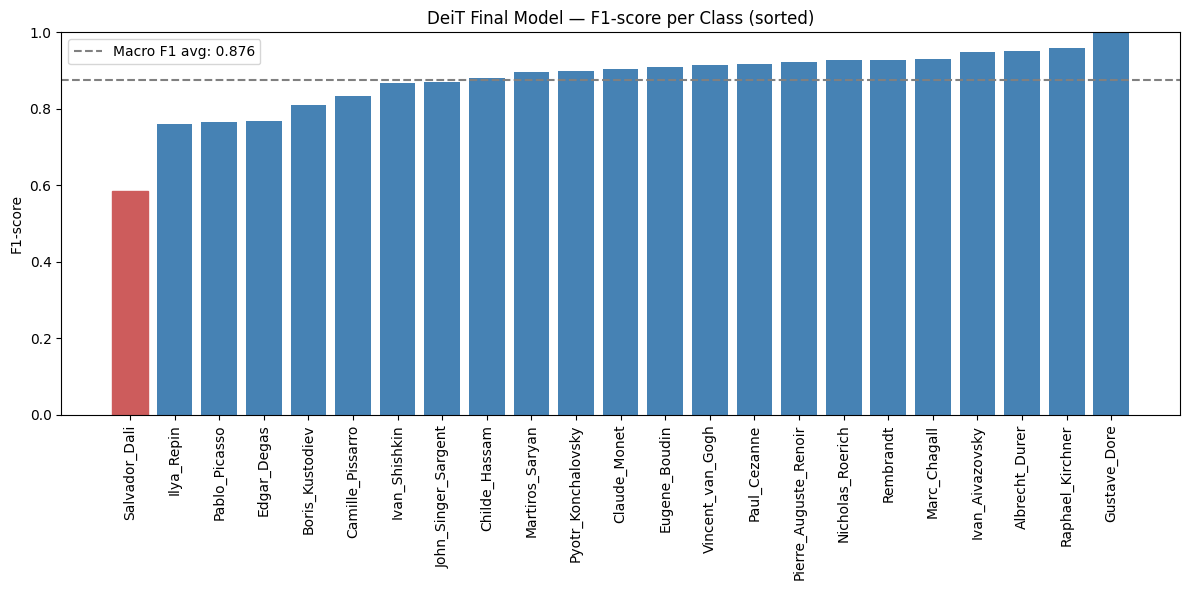

In [35]:
# Per-class F1 score bar chart
report_dict = classification_report(
    y_true_final, y_pred_final,
    target_names=class_names,
    output_dict=True
)

f1_scores = [report_dict[name]['f1-score'] for name in class_names]

# Sort ascending (worst classes on left)
sorted_idx = np.argsort(f1_scores)
sorted_names = np.array(class_names)[sorted_idx]
sorted_f1 = np.array(f1_scores)[sorted_idx]

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_names, sorted_f1, color='steelblue')

# Highlight weakest classes in red
for i, bar in enumerate(bars):
    if sorted_f1[i] < 0.70:
        bar.set_color('indianred')

plt.xticks(rotation=90)
plt.ylabel("F1-score")
plt.title("DeiT Final Model — F1-score per Class (sorted)")
plt.ylim(0, 1)
plt.axhline(y=report_dict['macro avg']['f1-score'], color='gray', linestyle='--',
            label=f"Macro F1 avg: {report_dict['macro avg']['f1-score']:.3f}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'deit_final_f1_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()

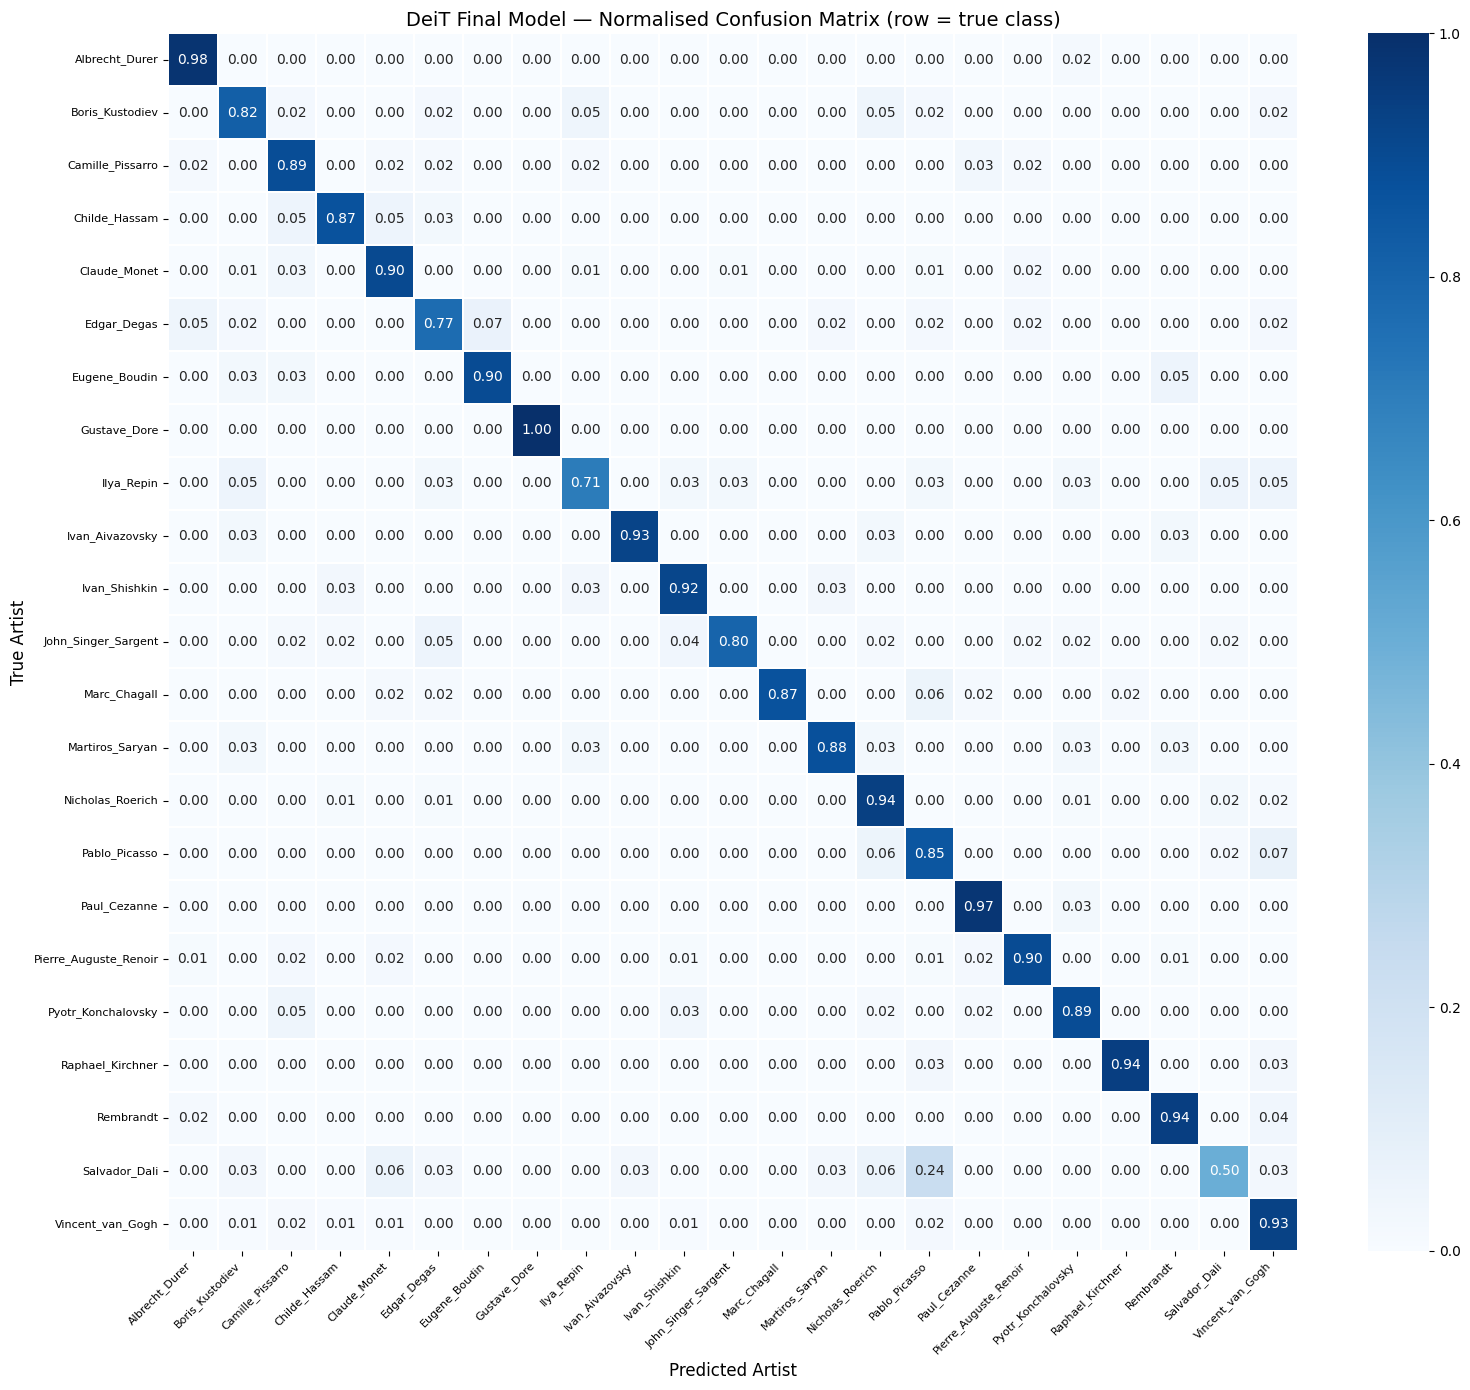

In [36]:
# Normalized confusion matrix (row = true class)
cm = confusion_matrix(y_true_final, y_pred_final)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.3, ax=ax
)
ax.set_xlabel('Predicted Artist', fontsize=12)
ax.set_ylabel('True Artist', fontsize=12)
ax.set_title('DeiT Final Model — Normalised Confusion Matrix (row = true class)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'deit_final_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

42/42 [==============================] - 1s 21ms/step


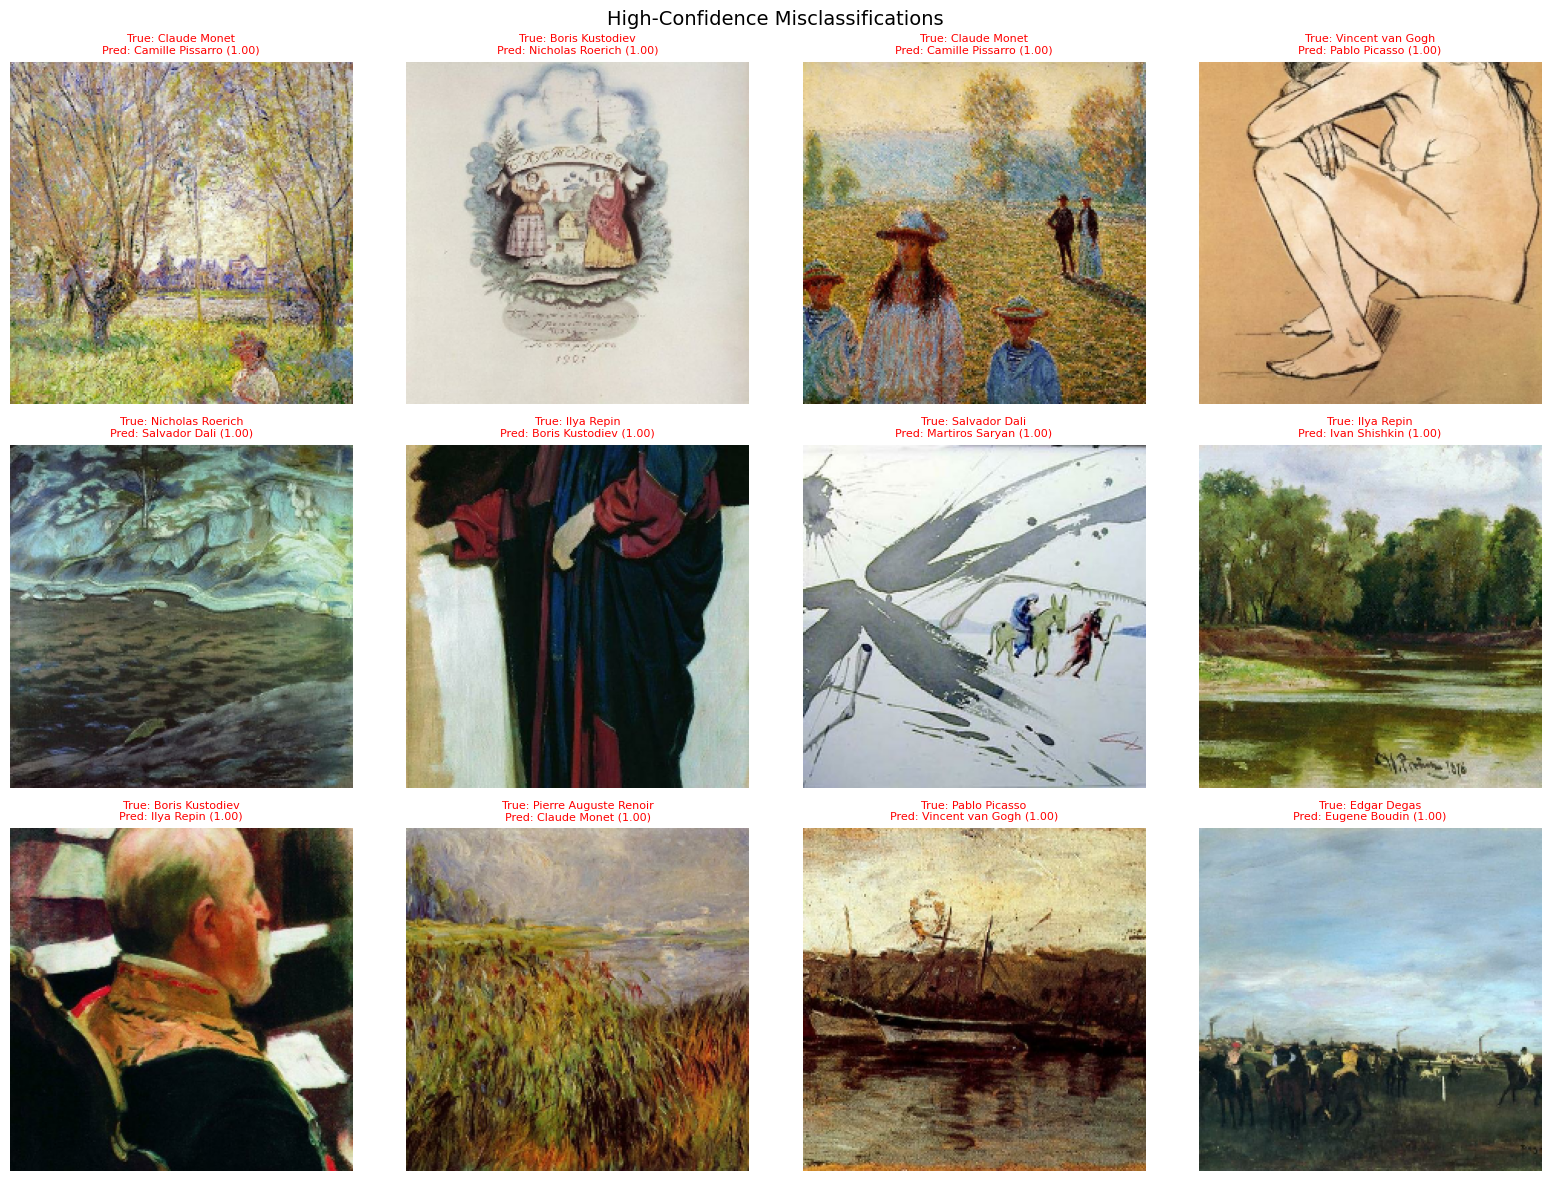

In [38]:
# to display de original images, instead of the preprocessed ones
# test_ds_deit has the images preprocessed for the model
def display_map(image, label):
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.uint8)
    return image, label

test_ds_display = (test_ds_raw
    .map(display_map, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Extract images
images = np.concatenate([x for x, y in test_ds_display], axis=0)

# Predictions with probabilities
y_pred_probs = deit_model_final.predict(test_ds_deit, verbose=1)

wrong_mask = y_pred_final != y_true_final

wrong_images = images[wrong_mask]
wrong_true   = y_true_final[wrong_mask]
wrong_pred   = y_pred_final[wrong_mask]
wrong_probs  = y_pred_probs[wrong_mask]
wrong_conf   = np.max(wrong_probs, axis=1)

# Top 12 highest-confidence mistakes
high_conf_idx = np.argsort(wrong_conf)[::-1][:12]

# Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for ax, idx in zip(axes.flatten(), high_conf_idx):
    ax.imshow(wrong_images[idx].astype("uint8"))
    ax.axis("off")

    true_name = class_names[wrong_true[idx]].replace('_', ' ')
    pred_name = class_names[wrong_pred[idx]].replace('_', ' ')

    conf = wrong_conf[idx]

    ax.set_title(
        f"True: {true_name}\nPred: {pred_name} ({conf:.2f})",
        fontsize=8,
        color='red'
    )

plt.suptitle("High-Confidence Misclassifications", fontsize=14)
plt.tight_layout()
plt.show()